# 子图动态路由
- 子图可以通过`Command(update=xx,goto=xxx,graph=Command.PARENT)`跳转到父图节点。这里没有`Command.GRANDPARENT`，如果想要条多层，可以通过在父层设置中转节点，一层一层往上跳。
- 子图跳转节点返回值不能声明为Command[Literal['parent_node']],因为'parent_node'对子图目前不可见，但不声明这个返回值，图渲染又会有节点游离，可以通过`parent_builder.add_node("sub_graph", sub_graph,destinations=('node_b',))`中的destinations指定，这样跳转的节点就不会游离在图外了
- 父图不能向子图跳，因为子图对于父图来说是一个盲盒，父图不知道内部细节

2026-08-14 22:32:22.975 | INFO     | __main__:sub_node:14 - [子图] sub_node 执行


[父图] node_b 执行

最终结果: {'data': '初始 → 子图'}


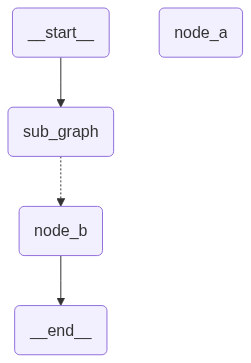

In [3]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from loguru import logger
from unstructured_client import destinations


# ==================== 子图 ====================
class SubState(TypedDict):
    data: str

def sub_node(state: SubState) -> Command:
    """子图节点：执行后动态路由回父图的 parent_router"""
    logger.info("[子图] sub_node 执行")
    return Command(
        update={"data": state["data"] + " → 子图"},
        goto="node_b",       # 路由到父图节点
        graph=Command.PARENT,       # 指定目标为父图
    )

sub_builder = StateGraph(state_schema=SubState)
sub_builder.add_node("sub_node", sub_node)
sub_builder.add_edge(START, "sub_node")
sub_graph = sub_builder.compile()

# ==================== 父图 ====================
class ParentState(TypedDict):
    data: str

def node_a(state: ParentState) -> ParentState:
    print("[父图] node_a 执行")
    return {"visited_a": True}

def node_b(state: ParentState) -> ParentState:
    print("[父图] node_b 执行")
    return {"visited_b": True}

parent_builder = StateGraph(state_schema=ParentState)
parent_builder.add_node(
    "sub_graph", sub_graph,
    destinations=('node_b',)
)

parent_builder.add_node("node_a", node_a)
parent_builder.add_node("node_b", node_b)
parent_builder.add_edge(START, "sub_graph")
parent_builder.add_edge("node_a", "node_b")
parent_builder.add_edge("node_b", END)

parent_graph = parent_builder.compile()

result = parent_graph.invoke({"data": "初始"})
print(f"\n最终结果: {result}")

from IPython.display import display
display(parent_graph)